In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

os.makedirs("outputs", exist_ok=True)

In [2]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


# PyTorch Tensors

## Question 1

In [3]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

for name, tensor in [("a", a), ("b", b), ("c", c)]:
    print(f"Tensor {name}:")
    print(tensor)
    print(f"Shape:  {tensor.shape}")
    print(f"Dtype:  {tensor.dtype}")
    print(f"Device: {tensor.device}")
    print()

# These tensors are currently on the CPU unless they are explicitly moved to the GPU.
# In a training loop, the model weights and the input tensors must be on the same device,
# or PyTorch will raise an error and the computation will not run correctly.

Tensor a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape:  torch.Size([2, 3])
Dtype:  torch.float32
Device: cpu

Tensor b:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
Shape:  torch.Size([2, 3])
Dtype:  torch.float32
Device: cpu

Tensor c:
tensor([1., 1., 1., 1.])
Shape:  torch.Size([4])
Dtype:  torch.float32
Device: cpu



## Question 2

In [4]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

print("Tensor x:")
print(x)

print("\nElement-wise square root:")
print(torch.sqrt(x))

print("\nSum:")
print(x.sum())

print("\nMean:")
print(x.mean())

print("\nIndex of maximum value:")
print(x.argmax())

# In a classifier that outputs scores for 1,000 classes, .argmax() gives the
# index of the class with the highest score, which is the model's predicted class.

Tensor x:
tensor([ 1.,  4.,  9., 16., 25.])

Element-wise square root:
tensor([1., 2., 3., 4., 5.])

Sum:
tensor(55.)

Mean:
tensor(11.)

Index of maximum value:
tensor(4)


## Question 3

In [5]:
a_gpu = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back = a_gpu.cpu()
a_numpy = a_back.numpy()

print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

# PyTorch requires .cpu() before .numpy() because NumPy arrays live in CPU memory,
# not GPU memory. This means a tensor must be moved back to the CPU before NumPy
# can access and represent its values.

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


## Question 4

In [6]:
t = torch.arange(24).float()

print("Original tensor:")
print(t)
print(f"Original shape: {t.shape}")

t_4_6 = t.reshape(4, 6)
print("\nReshaped to (4, 6):")
print(t_4_6)
print(f"Shape: {t_4_6.shape}")

t_2_3_4 = t.reshape(2, 3, 4)
print("\nReshaped to (2, 3, 4):")
print(t_2_3_4)
print(f"Shape: {t_2_3_4.shape}")

t_with_batch = t_4_6.unsqueeze(0)
print("\nAfter adding a new dimension at position 0:")
print(t_with_batch)
print(f"Shape: {t_with_batch.shape}")

# When you process one image at a time, you use unsqueeze(0) to add a batch dimension.
# This matters because neural networks expect batched input with shape
# (batch_size, channels, height, width), even if the batch contains only one image.

Original tensor:
tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23.])
Original shape: torch.Size([24])

Reshaped to (4, 6):
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10., 11.],
        [12., 13., 14., 15., 16., 17.],
        [18., 19., 20., 21., 22., 23.]])
Shape: torch.Size([4, 6])

Reshaped to (2, 3, 4):
tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]],

        [[12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.]]])
Shape: torch.Size([2, 3, 4])

After adding a new dimension at position 0:
tensor([[[ 0.,  1.,  2.,  3.,  4.,  5.],
         [ 6.,  7.,  8.,  9., 10., 11.],
         [12., 13., 14., 15., 16., 17.],
         [18., 19., 20., 21., 22., 23.]]])
Shape: torch.Size([1, 4, 6])


## Question 5

In [7]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

numpy_product = np_a @ np_b
torch_product = t_a @ t_b

print("NumPy matrix product:")
print(numpy_product)

print("\nPyTorch matrix product:")
print(torch_product)

print("\nDo the results match?")
print(np.allclose(numpy_product, torch_product.numpy()))

# In a single neural network layer, matrix multiplication applies the layer's
# learned weights to the input data. This is how the model transforms the input
# into a new representation before adding bias and applying an activation function.

NumPy matrix product:
[[19. 22.]
 [43. 50.]]

PyTorch matrix product:
tensor([[19., 22.],
        [43., 50.]])

Do the results match?
True


# Pretrained Models

## Question 1

In [8]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Starting from pretrained weights is extremely valuable when you are working
# under a deadline or a limited budget. Instead of training millions of parameters
# from scratch on a huge labeled dataset, you begin with a model that has already
# learned useful visual features such as edges, textures, and object shapes.
# That saves time, reduces compute cost, and often gives much better results
# when your own dataset is smaller than ImageNet.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]

Total parameters:     11,689,512
Trainable parameters: 11,689,512


## Question 2

In [9]:
print(model)

# In ResNet18, the final layer is named "fc".
# Its output size is 1000, which means the model produces scores for 1,000 ImageNet categories.

# The blocks named layer1 through layer4 are the deep feature extractor.
# In plain terms, a network is called "deep" because it has many stacked
# layers of computation. As data moves through these layers, the network
# learns increasingly complex visual patterns, from simple edges to
# higher-level shapes and object parts.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Question 3

In [10]:
model = model.to(device)
model.eval()
print("Model ready for inference.")

# .to(device) moves the model's parameters to the selected device, such as
# the GPU or CPU. The model and the input tensors must be on the same device,
# or PyTorch will raise an error during computation.

# model.eval() switches the model into evaluation mode. This changes the behavior
# of layers that act differently during training and inference, such as Dropout
# and BatchNorm. For example, BatchNorm uses stored running statistics in eval
# mode instead of batch statistics from the current input.

Model ready for inference.


## Question 4

In [11]:
preprocess = weights.transforms()
print(preprocess)

# The resize and crop steps make sure the image has the size and framing
# expected by the pretrained model. This gives the network a consistent input shape.

# ToTensor() converts the image into a PyTorch tensor and scales pixel values
# from the 0-255 range down to the 0-1 range.

# Normalization shifts and scales each channel using the mean and standard deviation
# from ImageNet. This matters because the pretrained ResNet18 weights were learned
# on images processed in exactly that way. Using ImageNet's mean and standard deviation
# keeps the new input distribution aligned with what the model saw during training,
# while generic values like mean=0.5 and std=0.5 would not match the training setup as well.

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


# Running Inference

## Question 1

In [12]:
import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

In [13]:
imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


In [14]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: Run inference inside a torch.no_grad() block
    with torch.no_grad():
        output = model(input_tensor)

    # Step 3: Convert raw scores (logits) to probabilities
    probabilities = torch.nn.functional.softmax(output[0], dim=0)

    # Step 4: Get the top 5 predictions using torch.topk
    top_probs, top_indices = torch.topk(probabilities, 5)

    # Step 5: Build and return a list of (class_name, probability) tuples
    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append((class_labels[idx.item()], prob.item()))
    return results

In [15]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")

# The top prediction makes sense. The model was trained on ImageNet's 1,000
# categories, not on the six Intel scene labels, so it does not need to output
# the literal word "mountain" to be reasonable. Labels such as "alp", "valley",
# and "promontory" clearly map onto a mountain scene, so the top-5 predictions
# are semantically consistent with the image.


Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


## Question 2

In [16]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]

    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")

# The model seems most confident on glacier and mountain images, where the top-1
# probabilities are very high and the predicted ImageNet labels map naturally to
# the scene, such as "alp" and "valley".
#
# It seems least confident on forest images, where the top-1 probability is very
# low and the predicted labels do not match the scene especially well.
#
# The overall pattern is that the model is more confident when a scene resembles
# specific ImageNet categories, and less confident when the image is broader or
# more scene-based than object-based.


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


## Question 3

In [17]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

# Logits are the raw scores produced by the network before normalization, so they
# can be any real values, including large positives and negatives. Softmax converts
# them into probabilities between 0 and 1 that sum to 1.
#
# Neural networks output logits internally because they work better with loss
# functions such as cross-entropy and are more numerically stable than probabilities.
#
# In a production pipeline that filters out low-confidence predictions, probabilities
# are usually more useful than logits because they are easier to interpret. A rule
# like "only keep predictions above 0.80 confidence" makes sense with probabilities,
# while raw logits are harder to compare directly across examples.
#
# In this example, the top probability is only 0.1689, which suggests that the model
# is not very confident about the forest image.

Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


## Question 4

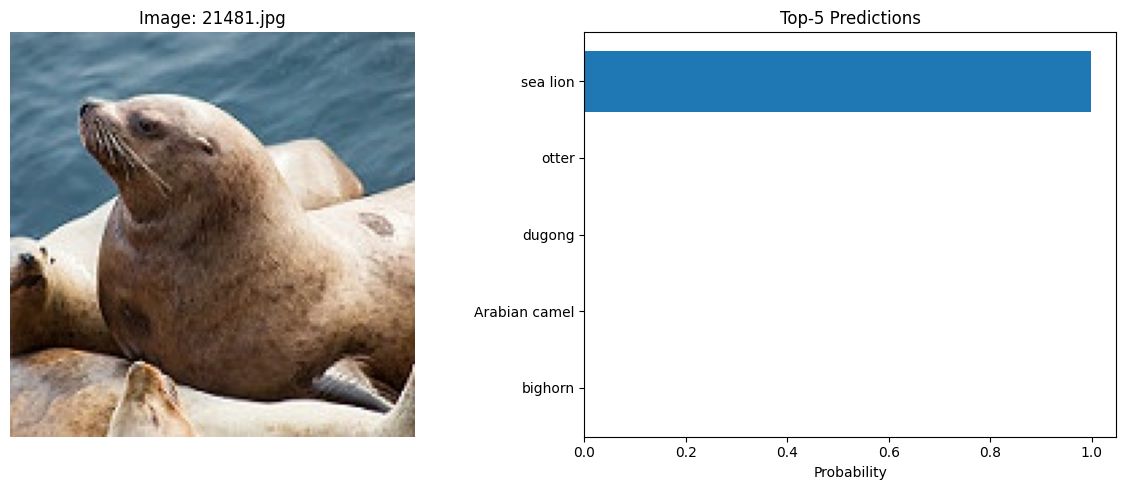

In [18]:
img, img_name = load_sample_image("sea")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: image
axes[0].imshow(img)
axes[0].set_title(f"Image: {img_name}")
axes[0].axis("off")

# Right panel: horizontal bar chart
class_names = [class_name for class_name, _ in preds]
probabilities = [prob for _, prob in preds]

axes[1].barh(class_names, probabilities)
axes[1].invert_yaxis()
axes[1].set_title("Top-5 Predictions")
axes[1].set_xlabel("Probability")

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()

# Logits are the raw scores produced by the network before normalization, so they
# can take any real values, including large positive and negative numbers. Softmax
# converts them into probabilities between 0 and 1 that sum to 1.
#
# Neural networks output logits internally because they work better with loss
# functions such as cross-entropy and are more numerically stable than probabilities.
#
# In a production pipeline that filters out low-confidence predictions, probabilities
# are usually more useful than logits because they are easier to interpret. A rule
# like "only keep predictions above 0.80 confidence" makes sense with probabilities,
# while raw logits are harder to compare directly across examples.
#
# In this example, the top probability is only 0.1689, which suggests that the model
# is not very confident about the forest image.